# 04 Preprocessing — Men's

This notebook constructs matchup-level features for all datasets (training, Stage 1 grid, Stage 2 grid). The dominant pattern from research is **difference features**: `TeamA_stat - TeamB_stat` for each matchup.

**Feature tiers (from EDA and research):**
1. Massey top systems rank difference (POM, SAG, MOR, WLK avg)
2. Seed difference
3. Efficiency differences (OffEff, DefEff, NetEff)
4. Win percentage and point differential differences
5. Shooting and box score stat differences
6. Conference strength (power conference flag)

**Training data augmentation**: "Flip and double" — each training matchup appears twice with features and label negated/flipped, preventing the model from learning ordering artifacts.

**Inputs**:
- From `03_data_split/mens/`: `tourney_matchups.parquet`, `prediction_grid_stage1.parquet`, `prediction_grid_stage2.parquet`
- From `01_data_joining/mens/`: `team_season_stats.parquet`, `tourney_seeds.parquet`, `massey_ordinals_pre_tourney.parquet`, `team_metadata.parquet`

**Outputs** (to S3 `04_preprocessing/mens/`):
1. `train_features.parquet` — training matchups with features, labels, and fold assignments (flip-doubled)
2. `stage1_features.parquet` — Stage 1 grid with features and labels where available
3. `stage2_features.parquet` — Stage 2 grid with features (2026 predictions)
4. `feature_columns.parquet` — list of feature column names for modeling

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

#### Functions

In [2]:
def read_parquet_joining(filename):
    """Read parquet from 01_data_joining on S3 or local."""
    try:
        return pd.read_parquet(f"s3://{BUCKET}/01_data_joining/{GENDER}/{filename}")
    except Exception:
        return pd.read_parquet(f"../01_data_joining/output/{filename}")

def read_parquet_split(filename):
    """Read parquet from 03_data_split on S3 or local."""
    try:
        return pd.read_parquet(f"s3://{BUCKET}/03_data_split/{GENDER}/{filename}")
    except Exception:
        return pd.read_parquet(f"../03_data_split/output/{filename}")

In [3]:
def build_matchup_features(matchup_df, team_stats, seeds, massey, team_meta, elo, recent_form):
    """
    For each matchup (Season, TeamA, TeamB), compute difference features.
    TeamA is always the lower-ID team (submission format).
    Features are computed as TeamA_stat - TeamB_stat.
    """
    df = matchup_df.copy()
    
    # --- Seed features ---
    seed_cols = seeds[['Season', 'TeamID', 'SeedNum']]
    df = df.merge(seed_cols, left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={'SeedNum': 'SeedA'}).drop(columns=['TeamID'], errors='ignore')
    df = df.merge(seed_cols, left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={'SeedNum': 'SeedB'}).drop(columns=['TeamID'], errors='ignore')
    df['SeedDiff'] = df['SeedA'] - df['SeedB']
    
    # --- Massey features ---
    massey_cols_to_use = ['TopSystemsAvgRank', 'AvgOrdinalRank']
    # Also include individual top systems if available
    for sys in ['POM', 'SAG', 'MOR', 'WLK']:
        if sys in massey.columns:
            massey_cols_to_use.append(sys)
    
    massey_subset = massey[['Season', 'TeamID'] + massey_cols_to_use]
    
    df = df.merge(massey_subset, left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={c: f'{c}_A' for c in massey_cols_to_use}).drop(columns=['TeamID'], errors='ignore')
    df = df.merge(massey_subset, left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={c: f'{c}_B' for c in massey_cols_to_use}).drop(columns=['TeamID'], errors='ignore')
    
    for col in massey_cols_to_use:
        df[f'{col}Diff'] = df[f'{col}_A'] - df[f'{col}_B']
    
    # --- Team season stat features ---
    stat_cols = ['WinPct', 'WeightedWinPct', 'WinStreak', 'LossStreak',
                 'AvgPointDiff', 'OffEff', 'DefEff', 'NetEff',
                 'FGPct', 'FG3Pct', 'FTPct',
                 'AvgTO', 'AvgStl', 'AvgBlk', 'AvgOR', 'AvgDR', 'AvgAst',
                 'OppFGPct', 'OppFG3Pct', 'AvgPoss',
                 'SOS', 'ScoreStd', 'QualityWinPct', 'ConfTourneyChamp',
                 'ConfRegSeasonChamp', 'PowerConfWinPct',
                 'Top25WinPct', 'Top10WinPct', 'Top5WinPct',
                 # Home/Road win percentages
                 'HomeWinPct', 'RoadWinPct',
                 'HomeTop25WinPct', 'HomeTop10WinPct', 'HomeTop5WinPct',
                 'RoadTop25WinPct', 'RoadTop10WinPct', 'RoadTop5WinPct',
                 # Margin features
                 'FGM_Margin', 'FGA_Margin', 'FGM3_Margin',
                 'FTM_Margin', 'FTA_Margin',
                 'OR_Margin', 'DR_Margin', 'DRB_Pct', 'TotalReb_Margin',
                 'TO_Margin', 'Stl_Margin', 'Blk_Margin', 'Ast_Margin',
                 # Advanced shooting
                 'eFGPct', 'TSPct', 'FTr', 'ThreePAr',
                 'OppeFGPct', 'OppTSPct']
    # Only use columns that exist
    stat_cols = [c for c in stat_cols if c in team_stats.columns]
    
    stats_subset = team_stats[['Season', 'TeamID'] + stat_cols]
    
    df = df.merge(stats_subset, left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={c: f'{c}_A' for c in stat_cols}).drop(columns=['TeamID'], errors='ignore')
    df = df.merge(stats_subset, left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={c: f'{c}_B' for c in stat_cols}).drop(columns=['TeamID'], errors='ignore')
    
    for col in stat_cols:
        df[f'{col}Diff'] = df[f'{col}_A'] - df[f'{col}_B']
    
    # --- Conference / power conference features ---
    meta_subset = team_meta[['Season', 'TeamID', 'IsPowerConf']]
    df = df.merge(meta_subset, left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={'IsPowerConf': 'IsPowerConfA'}).drop(columns=['TeamID'], errors='ignore')
    df = df.merge(meta_subset, left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={'IsPowerConf': 'IsPowerConfB'}).drop(columns=['TeamID'], errors='ignore')
    df['IsPowerConfDiff'] = df['IsPowerConfA'] - df['IsPowerConfB']
    
    # --- Elo features ---
    elo_subset = elo[['Season', 'TeamID', 'Elo']]
    df = df.merge(elo_subset, left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={'Elo': 'Elo_A'}).drop(columns=['TeamID'], errors='ignore')
    df = df.merge(elo_subset, left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={'Elo': 'Elo_B'}).drop(columns=['TeamID'], errors='ignore')
    df['EloDiff'] = df['Elo_A'] - df['Elo_B']
    
    # --- Recent form features ---
    recent_cols = ['RecentWinPct', 'RecentAvgPointDiff', 'RecentOffEff', 'RecentDefEff', 'RecentNetEff', 'RecentFGPct']
    recent_cols = [c for c in recent_cols if c in recent_form.columns]
    
    recent_subset = recent_form[['Season', 'TeamID'] + recent_cols]
    df = df.merge(recent_subset, left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={c: f'{c}_A' for c in recent_cols}).drop(columns=['TeamID'], errors='ignore')
    df = df.merge(recent_subset, left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'], how='left')
    df = df.rename(columns={c: f'{c}_B' for c in recent_cols}).drop(columns=['TeamID'], errors='ignore')
    
    for col in recent_cols:
        df[f'{col}Diff'] = df[f'{col}_A'] - df[f'{col}_B']
    
    # --- Interaction features ---
    df['Seed_x_Rank'] = df['SeedDiff'] * df['TopSystemsAvgRankDiff']
    
    return df

In [4]:
def get_feature_columns(df):
    """
    Return list of feature columns (all Diff columns plus seed values and interactions).
    Excludes ID, Season, TeamA, TeamB, Label, Fold, IsStage1Val, and raw per-team columns.
    """
    diff_cols = [c for c in df.columns if c.endswith('Diff')]
    extra_features = ['SeedA', 'SeedB', 'Seed_x_Rank']
    extra_features = [c for c in extra_features if c in df.columns]
    return diff_cols + extra_features

In [5]:
def flip_and_double(df, feature_cols, label_col='Label'):
    """
    Augment training data by adding mirror of each matchup.
    For the flipped copy: negate all difference features and flip the label.
    This prevents the model from learning artifacts based on team ID ordering.
    """
    original = df.copy()
    flipped = df.copy()
    
    # Negate all difference features
    diff_cols = [c for c in feature_cols if c.endswith('Diff')]
    for col in diff_cols:
        flipped[col] = -flipped[col]
    
    # Swap SeedA/SeedB if present
    if 'SeedA' in flipped.columns and 'SeedB' in flipped.columns:
        flipped['SeedA'], flipped['SeedB'] = flipped['SeedB'].copy(), flipped['SeedA'].copy()
    
    # Flip label
    if label_col in flipped.columns:
        flipped[label_col] = 1 - flipped[label_col]
    
    # Swap TeamA/TeamB for identification
    flipped['TeamA'], flipped['TeamB'] = flipped['TeamB'].copy(), flipped['TeamA'].copy()
    
    return pd.concat([original, flipped], ignore_index=True)

#### Constants

In [6]:
BUCKET = "march-machine-learning-mania-2026"
GENDER = "mens"
STAGE = "04_preprocessing"
OUTPUT_PREFIX = f"s3://{BUCKET}/{STAGE}/{GENDER}/"

LOCAL_OUTPUT = "output/"

#### Make output directory

In [7]:
os.makedirs(LOCAL_OUTPUT, exist_ok=True)

## 1. Load Data

In [8]:
# From 03_data_split
tourney_matchups = read_parquet_split("tourney_matchups.parquet")
grid_stage1 = read_parquet_split("prediction_grid_stage1.parquet")
grid_stage2 = read_parquet_split("prediction_grid_stage2.parquet")

# From 01_data_joining
team_stats = read_parquet_joining("team_season_stats.parquet")
seeds = read_parquet_joining("tourney_seeds.parquet")
massey = read_parquet_joining("massey_ordinals_pre_tourney.parquet")
team_meta = read_parquet_joining("team_metadata.parquet")
elo = read_parquet_joining("elo_ratings.parquet")
recent_form = read_parquet_joining("recent_form.parquet")

print(f"Tournament matchups: {tourney_matchups.shape}")
print(f"Stage 1 grid: {grid_stage1.shape}")
print(f"Stage 2 grid: {grid_stage2.shape}")
print(f"Team stats: {team_stats.shape}")
print(f"Seeds: {seeds.shape}")
print(f"Massey: {massey.shape}")
print(f"Team metadata: {team_meta.shape}")
print(f"Elo ratings: {elo.shape}")
print(f"Recent form: {recent_form.shape}")

Tournament matchups: (2585, 7)
Stage 1 grid: (261013, 5)
Stage 2 grid: (66430, 4)
Team stats: (13753, 84)
Seeds: (2694, 6)
Massey: (13764, 196)
Team metadata: (13753, 7)
Elo ratings: (13753, 3)
Recent form: (13753, 24)


## 2. Build Features for Training Data

In [9]:
train_feat = build_matchup_features(tourney_matchups, team_stats, seeds, massey, team_meta, elo, recent_form)

feature_cols = get_feature_columns(train_feat)
print(f"Training features built: {train_feat.shape}")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

# Check missing values in features
missing = train_feat[feature_cols].isnull().mean().sort_values(ascending=False)
print(f"\nFeature missing rates:")
for feat, rate in missing.items():
    if rate > 0:
        print(f"  {feat}: {rate:.3f}")
if (missing == 0).all():
    print("  No missing values!")

Training features built: (2585, 221)
Feature columns (74): ['SeedDiff', 'TopSystemsAvgRankDiff', 'AvgOrdinalRankDiff', 'POMDiff', 'SAGDiff', 'MORDiff', 'WLKDiff', 'WinPctDiff', 'WeightedWinPctDiff', 'WinStreakDiff', 'LossStreakDiff', 'AvgPointDiffDiff', 'OffEffDiff', 'DefEffDiff', 'NetEffDiff', 'FGPctDiff', 'FG3PctDiff', 'FTPctDiff', 'AvgTODiff', 'AvgStlDiff', 'AvgBlkDiff', 'AvgORDiff', 'AvgDRDiff', 'AvgAstDiff', 'OppFGPctDiff', 'OppFG3PctDiff', 'AvgPossDiff', 'SOSDiff', 'ScoreStdDiff', 'QualityWinPctDiff', 'ConfTourneyChampDiff', 'ConfRegSeasonChampDiff', 'PowerConfWinPctDiff', 'Top25WinPctDiff', 'Top10WinPctDiff', 'Top5WinPctDiff', 'HomeWinPctDiff', 'RoadWinPctDiff', 'HomeTop25WinPctDiff', 'HomeTop10WinPctDiff', 'HomeTop5WinPctDiff', 'RoadTop25WinPctDiff', 'RoadTop10WinPctDiff', 'RoadTop5WinPctDiff', 'FGM_MarginDiff', 'FGA_MarginDiff', 'FGM3_MarginDiff', 'FTM_MarginDiff', 'FTA_MarginDiff', 'OR_MarginDiff', 'DR_MarginDiff', 'DRB_PctDiff', 'TotalReb_MarginDiff', 'TO_MarginDiff', 'Stl_M

## 3. Flip and Double Training Data

Each matchup produces two rows: the original and its mirror (features negated, label flipped). This ensures the model cannot learn from the arbitrary lower-ID-first ordering.

In [10]:
train_augmented = flip_and_double(train_feat, feature_cols)

print(f"Before flip-and-double: {train_feat.shape}")
print(f"After flip-and-double: {train_augmented.shape}")
print(f"Label balance after: {train_augmented.Label.mean():.3f} (should be ~0.5)")

Before flip-and-double: (2585, 221)
After flip-and-double: (5170, 221)
Label balance after: 0.500 (should be ~0.5)


## 4. Build Features for Prediction Grids

Same feature construction for Stage 1 and Stage 2 grids. No flip-and-double needed — predictions are made in the canonical (lower-ID first) format.

In [11]:
stage1_feat = build_matchup_features(grid_stage1, team_stats, seeds, massey, team_meta, elo, recent_form)
print(f"Stage 1 features: {stage1_feat.shape}")

# Check feature coverage
s1_missing = stage1_feat[feature_cols].isnull().mean()
print(f"Stage 1 feature missing rates (top 5):")
for feat, rate in s1_missing.sort_values(ascending=False).head().items():
    print(f"  {feat}: {rate:.3f}")

Stage 1 features: (261013, 219)
Stage 1 feature missing rates (top 5):
  Seed_x_Rank: 0.965
  SeedDiff: 0.965
  SeedB: 0.820
  SeedA: 0.804
  SAGDiff: 0.503


In [12]:
stage2_feat = build_matchup_features(grid_stage2, team_stats, seeds, massey, team_meta, elo, recent_form)
print(f"Stage 2 features: {stage2_feat.shape}")

# Check feature coverage
s2_missing = stage2_feat[feature_cols].isnull().mean()
print(f"Stage 2 feature missing rates (top 5):")
for feat, rate in s2_missing.sort_values(ascending=False).head().items():
    print(f"  {feat}: {rate:.3f}")

Stage 2 features: (66430, 218)
Stage 2 feature missing rates (top 5):
  SAGDiff: 1.000
  Seed_x_Rank: 0.966
  SeedDiff: 0.966
  SeedA: 0.825
  SeedB: 0.802


## 5. Feature Sanity Checks

In [13]:
# Verify difference features are antisymmetric in training data
# After flip-and-double, the mean of every Diff feature should be ~0
diff_cols = [c for c in feature_cols if c.endswith('Diff')]
diff_means = train_augmented[diff_cols].mean()

print("Diff feature means after flip-and-double (should all be ~0):")
for feat, mean_val in diff_means.items():
    status = "OK" if abs(mean_val) < 0.01 else "CHECK"
    print(f"  {feat}: {mean_val:+.6f} [{status}]")

Diff feature means after flip-and-double (should all be ~0):
  SeedDiff: +0.000000 [OK]
  TopSystemsAvgRankDiff: -0.000000 [OK]
  AvgOrdinalRankDiff: -0.000000 [OK]
  POMDiff: +0.000000 [OK]
  SAGDiff: +0.000000 [OK]
  MORDiff: +0.000000 [OK]
  WLKDiff: +0.000000 [OK]
  WinPctDiff: -0.000000 [OK]
  WeightedWinPctDiff: +0.000000 [OK]
  WinStreakDiff: +0.000000 [OK]
  LossStreakDiff: +0.000000 [OK]
  AvgPointDiffDiff: +0.000000 [OK]
  OffEffDiff: +0.000000 [OK]
  DefEffDiff: -0.000000 [OK]
  NetEffDiff: +0.000000 [OK]
  FGPctDiff: -0.000000 [OK]
  FG3PctDiff: +0.000000 [OK]
  FTPctDiff: +0.000000 [OK]
  AvgTODiff: -0.000000 [OK]
  AvgStlDiff: -0.000000 [OK]
  AvgBlkDiff: +0.000000 [OK]
  AvgORDiff: -0.000000 [OK]
  AvgDRDiff: +0.000000 [OK]
  AvgAstDiff: +0.000000 [OK]
  OppFGPctDiff: +0.000000 [OK]
  OppFG3PctDiff: +0.000000 [OK]
  AvgPossDiff: +0.000000 [OK]
  SOSDiff: -0.000000 [OK]
  ScoreStdDiff: +0.000000 [OK]
  QualityWinPctDiff: +0.000000 [OK]
  ConfTourneyChampDiff: +0.000000 [O

In [14]:
# Quick check: do features correlate with labels in expected direction?
# SeedDiff should be negative (lower seed = better = more likely to win)
# TopSystemsAvgRankDiff should be negative (lower rank = better)
# WinPctDiff should be positive (higher win% = more likely to win)
key_features = ['SeedDiff', 'TopSystemsAvgRankDiff', 'WinPctDiff', 'NetEffDiff', 'AvgPointDiffDiff']
key_features = [f for f in key_features if f in train_feat.columns]

print("Feature-Label correlations (before flip-and-double):")
for feat in key_features:
    corr = train_feat[[feat, 'Label']].dropna().corr().iloc[0, 1]
    print(f"  {feat}: {corr:+.3f}")

Feature-Label correlations (before flip-and-double):
  SeedDiff: -0.492
  TopSystemsAvgRankDiff: -0.425
  WinPctDiff: +0.324
  NetEffDiff: +0.402
  AvgPointDiffDiff: +0.397


## 5b. Post-Feature-Engineering EDA

Now that all difference features are constructed, explore their relationship with the target label, check for redundancy, and understand feature distributions.

### 5b.1 Feature-Label Correlations (Full Ranking)

Rank all difference features by their Pearson correlation with the binary outcome label. This uses the pre-flip-and-double data to avoid artificial symmetry.

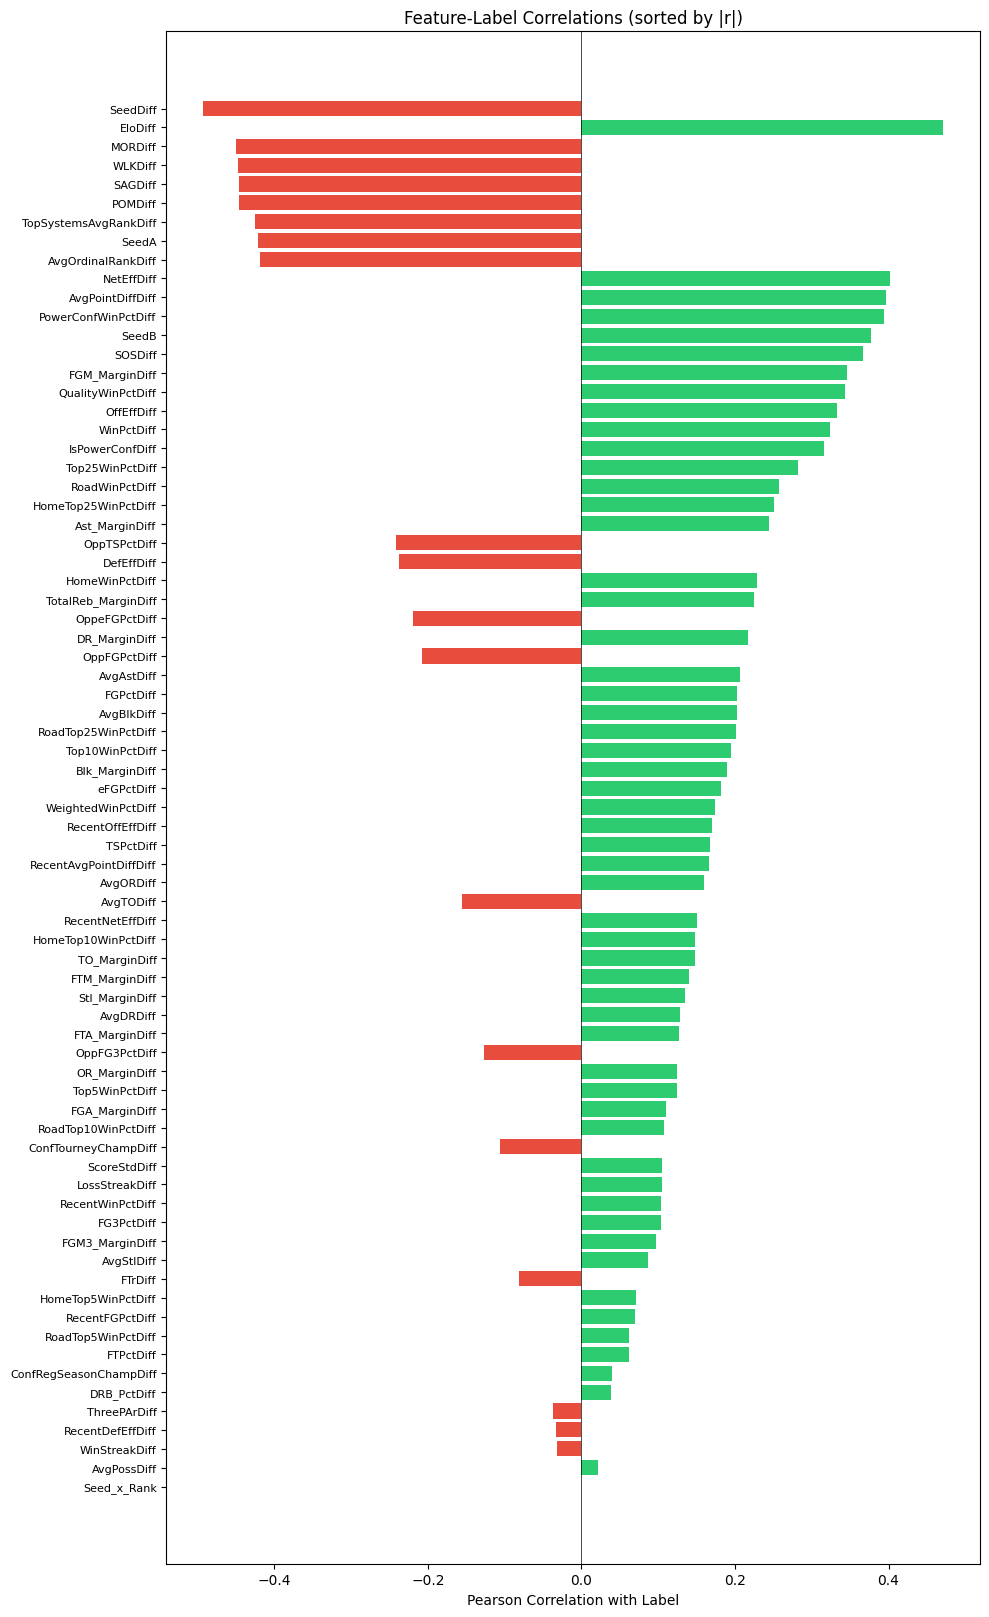

Top 15 features by |correlation|:
  SeedDiff                           : -0.4923
  EloDiff                            : +0.4710
  MORDiff                            : -0.4498
  WLKDiff                            : -0.4465
  SAGDiff                            : -0.4462
  POMDiff                            : -0.4455
  TopSystemsAvgRankDiff              : -0.4251
  SeedA                              : -0.4214
  AvgOrdinalRankDiff                 : -0.4182
  NetEffDiff                         : +0.4022
  AvgPointDiffDiff                   : +0.3967
  PowerConfWinPctDiff                : +0.3941
  SeedB                              : +0.3766
  SOSDiff                            : +0.3669
  FGM_MarginDiff                     : +0.3463


In [15]:
# Compute correlations with Label for all features (pre-flip-and-double)
corr_with_label = train_feat[feature_cols + ['Label']].corr()['Label'].drop('Label').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(corr_with_label) * 0.22)))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_label.values]
ax.barh(range(len(corr_with_label)), corr_with_label.values, color=colors)
ax.set_yticks(range(len(corr_with_label)))
ax.set_yticklabels(corr_with_label.index, fontsize=8)
ax.set_xlabel('Pearson Correlation with Label')
ax.set_title('Feature-Label Correlations (sorted by |r|)')
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{LOCAL_OUTPUT}feature_label_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 15 features by |correlation|:")
for feat, corr in corr_with_label.head(15).items():
    print(f"  {feat:35s}: {corr:+.4f}")

### 5b.2 Distribution of Top Predictive Features

Plot distributions of the top features split by outcome (Win=1 vs Loss=0). Good features should show clear separation between the two distributions.

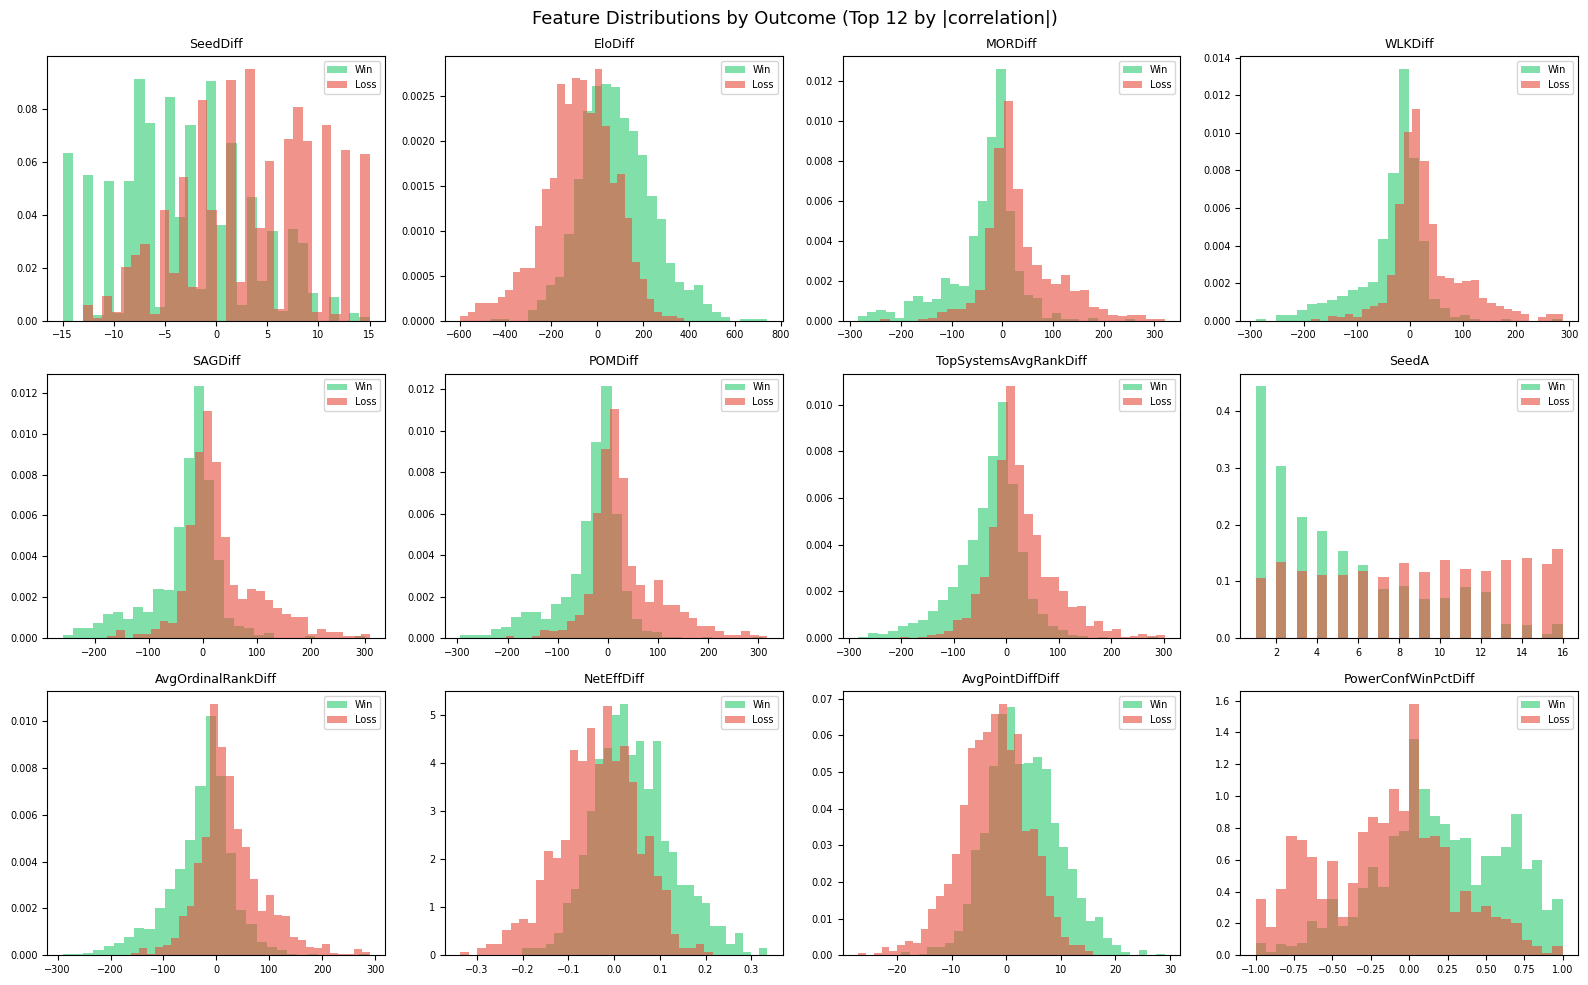

In [16]:
# Distribution plots for top 12 features by predictive power
top_feats = corr_with_label.head(12).index.tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    ax = axes[i]
    data = train_feat[[feat, 'Label']].dropna()
    wins = data[data['Label'] == 1][feat]
    losses = data[data['Label'] == 0][feat]
    ax.hist(wins, bins=30, alpha=0.6, label='Win', color='#2ecc71', density=True)
    ax.hist(losses, bins=30, alpha=0.6, label='Loss', color='#e74c3c', density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle('Feature Distributions by Outcome (Top 12 by |correlation|)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{LOCAL_OUTPUT}feature_distributions_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

### 5b.3 Feature Correlation Heatmap (Multicollinearity Check)

Identify groups of highly correlated features. Features with |r| > 0.9 are nearly redundant — tree models handle this well, but it's useful context for understanding feature groups and potential dimensionality reduction.

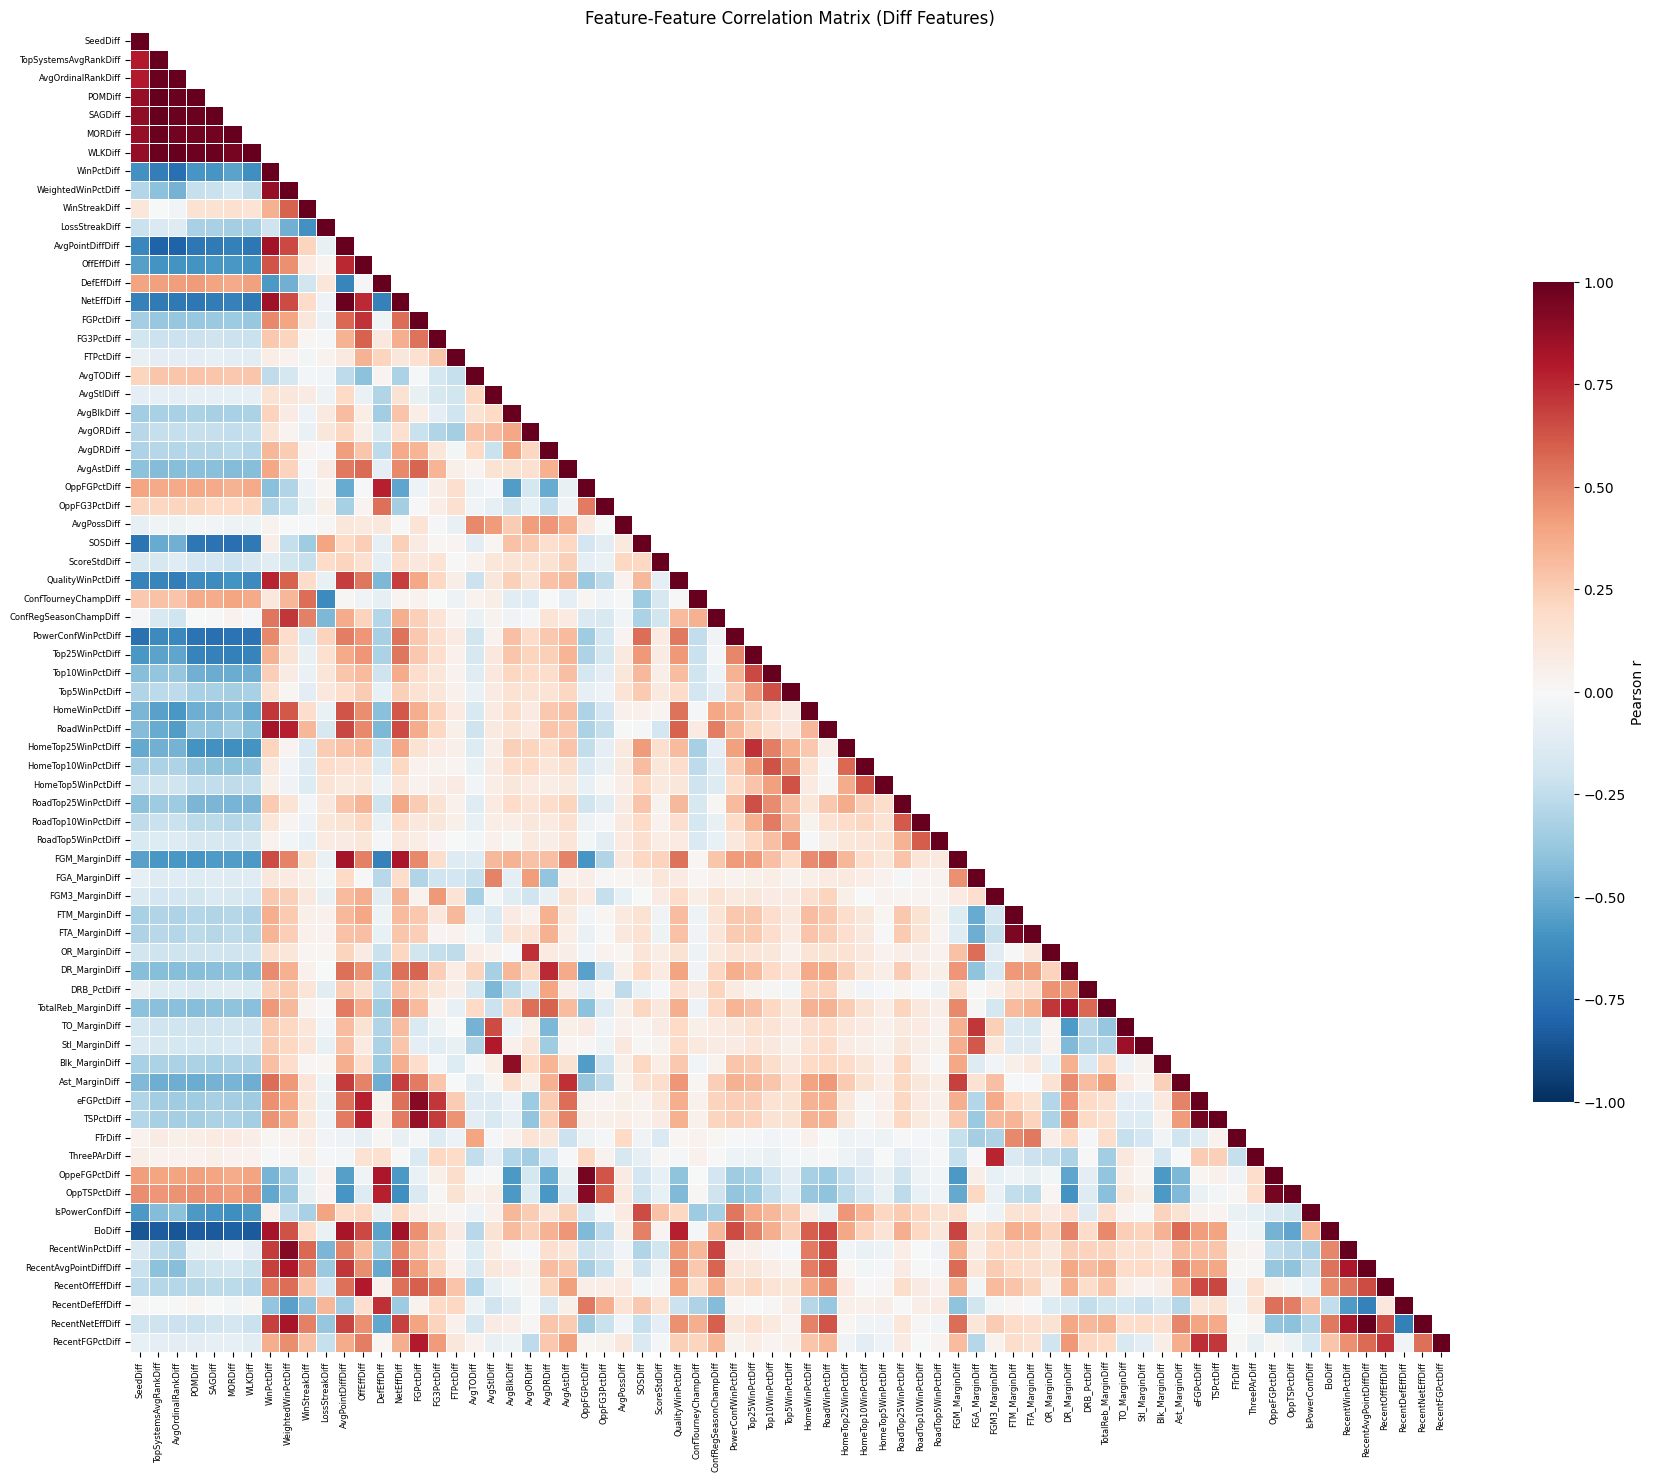

Highly correlated feature pairs (|r| > 0.9): 24
  RecentAvgPointDiffDiff         <-> RecentNetEffDiff              : +0.996
  TopSystemsAvgRankDiff          <-> SAGDiff                       : +0.995
  TopSystemsAvgRankDiff          <-> POMDiff                       : +0.994
  AvgOrdinalRankDiff             <-> WLKDiff                       : +0.993
  AvgOrdinalRankDiff             <-> SAGDiff                       : +0.992
  TopSystemsAvgRankDiff          <-> WLKDiff                       : +0.991
  TopSystemsAvgRankDiff          <-> AvgOrdinalRankDiff            : +0.991
  SAGDiff                        <-> WLKDiff                       : +0.989
  AvgPointDiffDiff               <-> NetEffDiff                    : +0.988
  POMDiff                        <-> SAGDiff                       : +0.987
  AvgOrdinalRankDiff             <-> POMDiff                       : +0.986
  TopSystemsAvgRankDiff          <-> MORDiff                       : +0.985
  POMDiff                        <-> WLK

In [17]:
# Correlation heatmap of all diff features
diff_feature_cols = [c for c in feature_cols if c.endswith('Diff')]
corr_matrix = train_feat[diff_feature_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=True, yticklabels=True,
            cbar_kws={'shrink': 0.6, 'label': 'Pearson r'})
ax.set_title('Feature-Feature Correlation Matrix (Diff Features)')
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig(f'{LOCAL_OUTPUT}feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag highly correlated pairs (|r| > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], r))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f"Highly correlated feature pairs (|r| > 0.9): {len(high_corr_pairs)}")
for f1, f2, r in high_corr_pairs:
    print(f"  {f1:30s} <-> {f2:30s}: {r:+.3f}")

### 5b.4 Missing Values by Feature Group

Understand missingness patterns — which feature groups have the most NaN values and why (e.g., detailed box score stats unavailable before 2003).

In [18]:
# Group features by category and show missing rates
def categorize_feature(feat):
    if 'Massey' in feat or 'Ordinal' in feat or feat in ['POMDiff', 'SAGDiff', 'MORDiff', 'WLKDiff', 'TopSystemsAvgRankDiff', 'AvgOrdinalRankDiff']:
        return 'Massey Rankings'
    elif 'Recent' in feat:
        return 'Recent Form'
    elif 'Margin' in feat:
        return 'Box Score Margins'
    elif any(x in feat for x in ['Home', 'Road']):
        return 'Home/Road Splits'
    elif any(x in feat for x in ['Top25', 'Top10', 'Top5', 'Quality', 'Power']):
        return 'Strength of Schedule'
    elif any(x in feat for x in ['FG', 'FT', 'Opp', 'eFG', 'TS', 'ThreeP']):
        return 'Shooting / Advanced'
    elif any(x in feat for x in ['Seed', 'Elo', 'Conf']):
        return 'Core (Seed/Elo/Conf)'
    elif any(x in feat for x in ['Win', 'PointDiff', 'Eff', 'SOS', 'Score', 'Poss']):
        return 'Team Performance'
    elif any(x in feat for x in ['TO', 'Stl', 'Blk', 'OR', 'DR', 'Ast', 'Reb']):
        return 'Box Score Stats'
    else:
        return 'Other'

missing_by_group = {}
for feat in feature_cols:
    group = categorize_feature(feat)
    rate = train_feat[feat].isnull().mean()
    if group not in missing_by_group:
        missing_by_group[group] = []
    missing_by_group[group].append((feat, rate))

print("Missing Value Rates by Feature Group (training data):")
print("=" * 65)
for group in sorted(missing_by_group.keys()):
    feats = missing_by_group[group]
    avg_rate = np.mean([r for _, r in feats])
    print(f"\n{group} ({len(feats)} features, avg missing: {avg_rate:.1%}):")
    for feat, rate in sorted(feats, key=lambda x: -x[1]):
        marker = " ***" if rate > 0.3 else ""
        print(f"  {feat:35s}: {rate:.1%}{marker}")

# Show missing by season to understand the pattern
print("\n\nMissing rate by season (sample feature: NetEffDiff):")
for season in sorted(train_feat['Season'].unique()):
    season_data = train_feat[train_feat['Season'] == season]
    rate = season_data['NetEffDiff'].isnull().mean()
    if rate > 0:
        print(f"  {season}: {rate:.0%} missing")

Missing Value Rates by Feature Group (training data):

Box Score Margins (12 features, avg missing: 43.9%):
  FGM_MarginDiff                     : 43.9% ***
  FGA_MarginDiff                     : 43.9% ***
  FGM3_MarginDiff                    : 43.9% ***
  FTM_MarginDiff                     : 43.9% ***
  FTA_MarginDiff                     : 43.9% ***
  OR_MarginDiff                      : 43.9% ***
  DR_MarginDiff                      : 43.9% ***
  TotalReb_MarginDiff                : 43.9% ***
  TO_MarginDiff                      : 43.9% ***
  Stl_MarginDiff                     : 43.9% ***
  Blk_MarginDiff                     : 43.9% ***
  Ast_MarginDiff                     : 43.9% ***

Box Score Stats (7 features, avg missing: 43.9%):
  AvgTODiff                          : 43.9% ***
  AvgStlDiff                         : 43.9% ***
  AvgBlkDiff                         : 43.9% ***
  AvgORDiff                          : 43.9% ***
  AvgDRDiff                          : 43.9% ***
  AvgAst

## 6. Save Outputs

In [19]:
# Save feature column names for downstream modeling
feature_cols_df = pd.DataFrame({'feature': feature_cols})

outputs = {
    'train_features': train_augmented,
    'stage1_features': stage1_feat,
    'stage2_features': stage2_feat,
    'feature_columns': feature_cols_df,
}

for name, df in outputs.items():
    try:
        s3_path = f"{OUTPUT_PREFIX}{name}.parquet"
        df.to_parquet(s3_path, index=False)
        print(f"Saved to S3: {s3_path} ({df.shape})")
    except Exception as e:
        print(f"S3 save failed for {name}: {e}")

Saved to S3: s3://march-machine-learning-mania-2026/04_preprocessing/mens/train_features.parquet ((5170, 221))
Saved to S3: s3://march-machine-learning-mania-2026/04_preprocessing/mens/stage1_features.parquet ((261013, 219))
Saved to S3: s3://march-machine-learning-mania-2026/04_preprocessing/mens/stage2_features.parquet ((66430, 218))
Saved to S3: s3://march-machine-learning-mania-2026/04_preprocessing/mens/feature_columns.parquet ((74, 1))


## 7. Output Summary

In [20]:
print("=" * 60)
print("PREPROCESSING SUMMARY — MEN'S")
print("=" * 60)

print(f"\ntrain_features:")
print(f"  Shape: {train_augmented.shape} (flip-doubled from {train_feat.shape[0]} matchups)")
print(f"  Label balance: {train_augmented.Label.mean():.3f}")
print(f"  Seasons: {train_augmented.Season.min()} - {train_augmented.Season.max()}")

print(f"\nstage1_features:")
print(f"  Shape: {stage1_feat.shape}")
print(f"  Rows with labels: {stage1_feat.Label.notna().sum() if 'Label' in stage1_feat.columns else 'N/A'}")

print(f"\nstage2_features:")
print(f"  Shape: {stage2_feat.shape}")

print(f"\nFeature columns ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  - {f}")

PREPROCESSING SUMMARY — MEN'S

train_features:
  Shape: (5170, 221) (flip-doubled from 2585 matchups)
  Label balance: 0.500
  Seasons: 1985 - 2025

stage1_features:
  Shape: (261013, 219)
  Rows with labels: 268

stage2_features:
  Shape: (66430, 218)

Feature columns (74):
  - SeedDiff
  - TopSystemsAvgRankDiff
  - AvgOrdinalRankDiff
  - POMDiff
  - SAGDiff
  - MORDiff
  - WLKDiff
  - WinPctDiff
  - WeightedWinPctDiff
  - WinStreakDiff
  - LossStreakDiff
  - AvgPointDiffDiff
  - OffEffDiff
  - DefEffDiff
  - NetEffDiff
  - FGPctDiff
  - FG3PctDiff
  - FTPctDiff
  - AvgTODiff
  - AvgStlDiff
  - AvgBlkDiff
  - AvgORDiff
  - AvgDRDiff
  - AvgAstDiff
  - OppFGPctDiff
  - OppFG3PctDiff
  - AvgPossDiff
  - SOSDiff
  - ScoreStdDiff
  - QualityWinPctDiff
  - ConfTourneyChampDiff
  - ConfRegSeasonChampDiff
  - PowerConfWinPctDiff
  - Top25WinPctDiff
  - Top10WinPctDiff
  - Top5WinPctDiff
  - HomeWinPctDiff
  - RoadWinPctDiff
  - HomeTop25WinPctDiff
  - HomeTop10WinPctDiff
  - HomeTop5WinPctDi